<a href="https://colab.research.google.com/github/SheteNikita-D/Machine-Learning-/blob/main/k_means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
dataset = pd.read_csv("/Mall_Customers.csv")
print(dataset.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
#Data Preprocessing

print(dataset.isnull().sum())
dataset.fillna(0)

print(dataset.duplicated().sum())
dataset.drop_duplicates()



CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
0


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
print(dataset.columns)


Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [ ]:
income_column = None
spending_column = None

for col in dataset.columns:

    col_lower = col.lower()

    if "income" in col_lower:
        income_column = col

    if "spending" in col_lower:
        spending_column = col

if income_column is None or spending_column is None:
    print("Available columns:")
    print(dataset.columns.tolist())
    raise ValueError("Could not find Income or Spending columns.")

print("Income column:", income_column)
print("Spending column:", spending_column)

X = dataset[[income_column, spending_column]].copy()

print("\nFeatures used for clustering:")
print(X.head())

Income column: Annual Income (k$)
Spending column: Spending Score (1-100)

Features used for clustering:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)

dataset["Cluster"] = kmeans.fit_predict(X)

print("\nClustered Data:")
print(dataset.head())


Clustered Data:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  


In [ ]:
from sklearn import cluster
new_customer = [[60, 12]]

cluster = kmeans.predict(new_customer)

print("Customer belongs to Cluster:", cluster[0])

Customer belongs to Cluster: 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


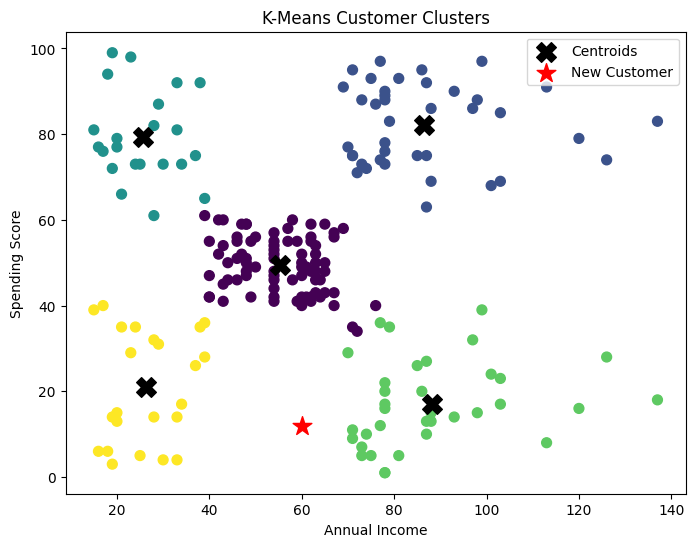

New customer belongs to Cluster: 3


In [ ]:
import matplotlib.pyplot as plt

# Predict cluster for new customer
new_cluster = kmeans.predict(new_customer)

plt.figure(figsize=(8, 6))

# Existing customers
plt.scatter(
    X[income_column],
    X[spending_column],
    c=dataset["Cluster"],
    cmap="viridis",
    s=50
)

# Cluster centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="X",
    s=200,
    c="black",
    label="Centroids"
)

# New customer - RED
plt.scatter(
    new_customer[0][0],
    new_customer[0][1],
    c="red",
    s=200,
    marker="*",
    label="New Customer"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means Customer Clusters")
plt.legend()
plt.show()

print("New customer belongs to Cluster:", new_cluster[0])